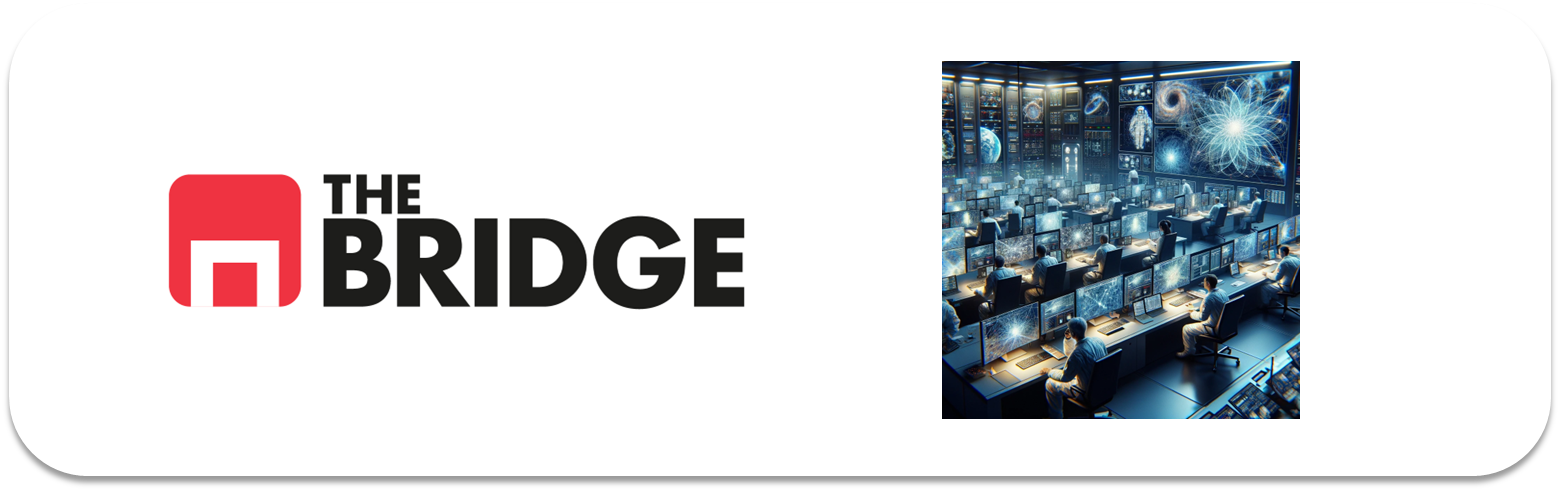

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [5]:
!pip install kagglehub


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

c:\Users\pablo.moran\Documents\GitHub\DS-Online-Pablo-Moran\venv_tf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf



from skimage.io import imread
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, decode_predictions, preprocess_input

In [3]:
import gc
from time import time
from sklearn.utils import shuffle

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [7]:
ROOT_PATH = path

In [8]:
os.listdir(path)

['seg_pred', 'seg_test', 'seg_train']

In [9]:
os.listdir(path + "/seg_train/seg_train/")


['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [10]:
TRAIN_PATH = ROOT_PATH + "/seg_train/seg_train/"
TEST_PATH = ROOT_PATH + "/seg_test/seg_test/"

In [11]:
os.listdir(TRAIN_PATH)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

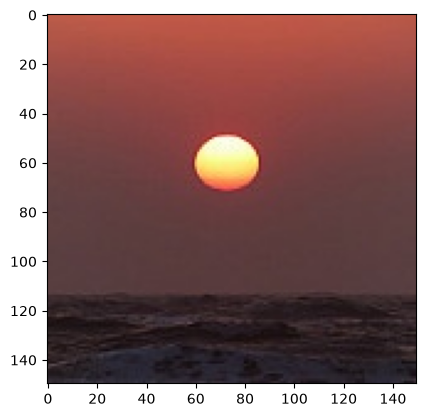

In [13]:
plt.imshow(imread(TRAIN_PATH + "/sea/" + "/11321.jpg"))
plt.show()

In [14]:
imread(TRAIN_PATH + "/sea/" + "/11321.jpg").shape

(150, 150, 3)

In [15]:
IMG_WIDTH = IMG_HEIGHT = 75

In [18]:
def read_data(directorio, reshape_dim=(IMG_HEIGHT, IMG_WIDTH)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        print(folder)
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):
                image = cv2.imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim)
                X.append(image)
                y.append(folder)
    return np.array(X), np.array(y)

In [19]:
def show_images_batch (paisajes, names=[], n_cols=5, size_scale=2):
    n_rows = ((len(paisajes)-1) // n_cols + 1)
    plt.figure(figsize=(n_cols*size_scale, n_rows * 1.1 * size_scale))
    for i, pet in enumerate(paisajes):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(pet, cmap='Greys')
        plt.axis('off')
        if len(names):
            plt.title(names[i])

In [20]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

buildings
forest
glacier
mountain
sea
street
buildings
forest
glacier
mountain
sea
street


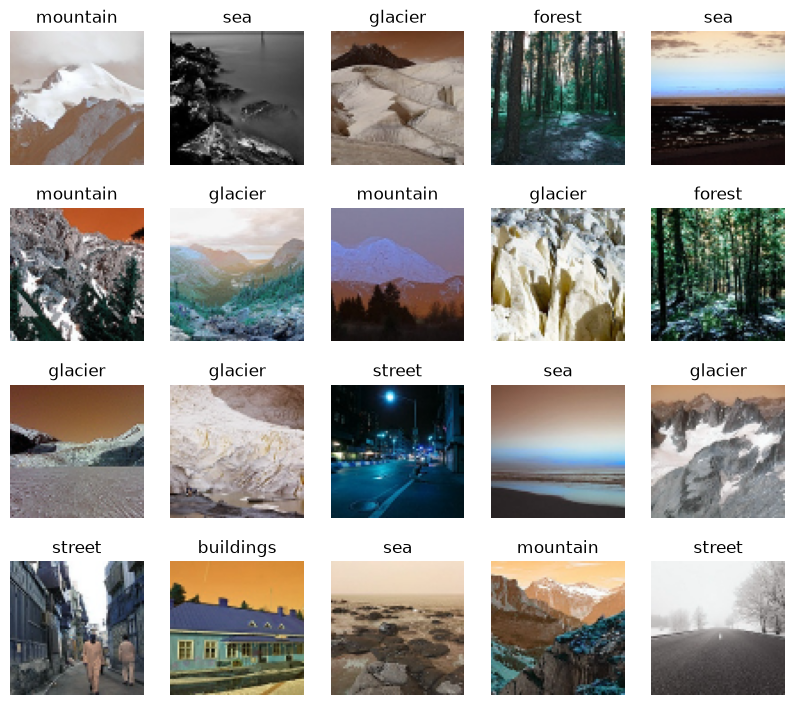

In [24]:
indices = np.random.randint(0,len(X_train), 20)
show_images_batch(X_train[indices], names = y_train[indices], n_cols=5)


In [25]:
X_train.shape

(14034, 75, 75, 3)

In [26]:
X_train.size

236823750

In [27]:
pd.Series(y_train).value_counts(True)*100

mountain     17.899387
glacier      17.129828
street       16.973065
sea          16.203506
forest       16.182129
buildings    15.612085
Name: proportion, dtype: float64

In [28]:
X_train = (X_train/127.5) -1
X_test = (X_test/127.5) -1

In [30]:
from keras.applications import InceptionV3

In [31]:
temp_model = InceptionV3(include_top = False,
                         weights='imagenet', input_shape=(75,75,3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [33]:
temp_model.input

<KerasTensor shape=(None, 75, 75, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [34]:
temp_model.output

<KerasTensor shape=(None, 1, 1, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_310>

In [35]:
del temp_model
gc.collect()

1000

In [38]:
import tensorflow as tf
from tensorflow import keras

In [56]:
IMG_HEIGHT = IMG_WIDTH = 75
base_model = InceptionV3(include_top=False, weights='imagenet',
                         input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

for layer in base_model.layers:
    layer.trainable = False

def prepare_model(base_model=base_model):
    
    x = keras.layers.Flatten()(base_model.output)
    
    x = keras.layers.Dense(2048, activation = 'relu')(x)
    x = keras.layers.Dropout(rate=0.25)(x)
    
    x = keras.layers.Dense(6, activation = 'softmax')(x)
    
    model = keras.Model(base_model.input,x)
    
    model.compile(
        optimizer = "adam",
        loss = "sparse_categorical_crossentropy",
        metrics = ['acc']
    )
    return model

model = prepare_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_282 (Conv2D) │ (None, 37, 37,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_282[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_282      │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_283 (Conv2D) │ (None, 35, 35,    │      9,216 │ activation_282[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_283[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_283      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_284 (Conv2D) │ (None, 35, 35,    │     18,432 │ activation_283[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_284[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_284      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 17, 17,    │          0 │ activation_284[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_285 (Conv2D) │ (None, 17, 17,    │      5,120 │ max_pooling2d_12… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_285[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_285      │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_286 (Conv2D) │ (None, 15, 15,    │    138,240 │ activation_285[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_286[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_286      │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 4,208,646 (16.05 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [57]:
X_train.shape[0]*.8

11227.2

In [58]:
instancias_train = len(X_train)

for i in range(1,5):
    print(f"Batch_size: {32*i}, num_step_per_epoch: {round((instancias_train*.8)/(32*i))}")

Batch_size: 32, num_step_per_epoch: 351
Batch_size: 64, num_step_per_epoch: 175
Batch_size: 96, num_step_per_epoch: 117
Batch_size: 128, num_step_per_epoch: 88


In [59]:
targets = pd.Series(y_train)


In [60]:
mapa ={tipo:indice for indice, tipo in enumerate(targets.unique())}
mapa

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [61]:
y_train_num = np.array([mapa[y] for y in y_train])
y_test_num = np.array([mapa[y] for y in y_test])

In [62]:
BATCH_SIZE = 128

In [63]:
t_zero = time()

In [64]:
earlys = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

In [65]:
X_train_s, y_train_s = shuffle(X_train, y_train_num)

In [67]:
model = prepare_model()
history = model.fit(X_train_s,
                    y_train_s,
                    batch_size = BATCH_SIZE,
                    validation_split=0.2,
                    epochs=40,
                    callbacks=earlys)

tiempo = round(time()-t_zero, 3)


Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 70s 714ms/step - acc: 0.6972 - loss: 0.9187 - val_acc: 0.7752 - val_loss: 0.6065
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 660ms/step - acc: 0.8256 - loss: 0.4734 - val_acc: 0.7905 - val_loss: 0.5707
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 657ms/step - acc: 0.8777 - loss: 0.3438 - val_acc: 0.7809 - val_loss: 0.5937
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 663ms/step - acc: 0.9205 - loss: 0.2331 - val_acc: 0.7841 - val_loss: 0.6162
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 664ms/step - acc: 0.9553 - loss: 0.1564 - val_acc: 0.7859 - val_loss: 0.6564
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 62s 701ms/step - acc: 0.9768 - loss: 0.0965 - val_acc: 0.7841 - val_loss: 0.7093
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 666ms/step - acc: 0.9890 - loss: 0.0575 - val_acc: 0.7880 - val_loss: 0.7178
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 61s 695ms/step - acc: 0.9959 - loss: 0.0356 - val_acc: 0.7884 - val_loss: 0.7620
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 68s 780ms/

In [68]:
print(tiempo)

1431.286


In [69]:
model.evaluate(X_test, y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - acc: 0.7873 - loss: 0.5714


[0.5713827610015869, 0.7873333096504211]

In [70]:
y_pred = [np.argmax(prediction) for prediction in model.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step


In [71]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [72]:
#Volver del numero a la palabra
inverse_map = {valor:clave for clave, valor in mapa.items()}
y_test_label = [inverse_map[y] for y in y_test_num]
y_pred_label = [inverse_map[y] for y in y_pred]

print(classification_report(y_test_label, y_pred_label))

              precision    recall  f1-score   support

   buildings       0.80      0.84      0.82       437
      forest       0.94      0.96      0.95       474
     glacier       0.72      0.67      0.69       553
    mountain       0.69      0.71      0.70       525
         sea       0.78      0.74      0.76       510
      street       0.80      0.85      0.82       501

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



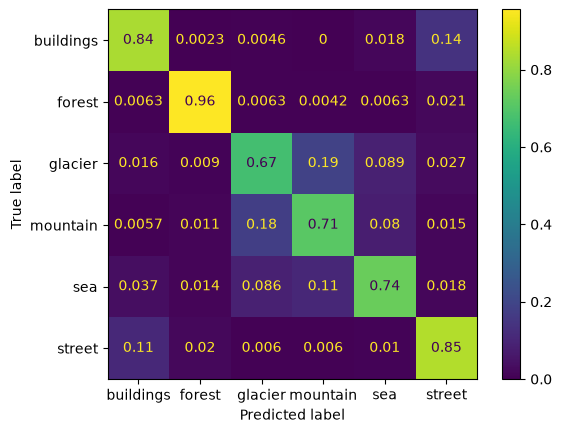

In [74]:
ConfusionMatrixDisplay.from_predictions(y_test_label, y_pred_label, normalize="true")
plt.show()

In [75]:
del model
del history
gc.collect()

53934

In [76]:
IMG_HEIGHT = IMG_WIDTH = 75
base_model = InceptionV3(include_top=False, weights='imagenet',
                         input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

#for layer in base_model.layers:
    #layer.trainable = False

def prepare_model(base_model=base_model):
    
    x = keras.layers.Flatten()(base_model.output)
    
    x = keras.layers.Dense(2048, activation = 'relu')(x)
    x = keras.layers.Dropout(rate=0.25)(x)
    
    x = keras.layers.Dense(6, activation = 'softmax')(x)
    
    model = keras.Model(base_model.input,x)
    
    model.compile(
        optimizer = "adam",
        loss = "sparse_categorical_crossentropy",
        metrics = ['acc']
    )
    return model

model = prepare_model()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_376 (Conv2D) │ (None, 37, 37,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_376[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_376      │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_377 (Conv2D) │ (None, 35, 35,    │      9,216 │ activation_376[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_377[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_377      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_378 (Conv2D) │ (None, 35, 35,    │     18,432 │ activation_377[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_378[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_378      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 17, 17,    │          0 │ activation_378[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_379 (Conv2D) │ (None, 17, 17,    │      5,120 │ max_pooling2d_16… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_379[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_379      │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_380 (Conv2D) │ (None, 15, 15,    │    138,240 │ activation_379[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_380[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_380      │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 25,976,998 (99.09 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [77]:
t_zero = time()
model = prepare_model()
history = model.fit(X_train_s,
                    y_train_s,
                    batch_size = BATCH_SIZE,
                    validation_split=0.2,
                    epochs=40,
                    callbacks=earlys)

tiempo = round(time()-t_zero, 3)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 384s 4s/step - acc: 0.6469 - loss: 1.1051 - val_acc: 0.1592 - val_loss: 5725.9419
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - acc: 0.7628 - loss: 0.9777 - val_acc: 0.1824 - val_loss: 306309.1250
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - acc: 0.7532 - loss: 0.8710 - val_acc: 0.1785 - val_loss: 37402.3828
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - acc: 0.8111 - loss: 0.6060 - val_acc: 0.6719 - val_loss: 1.0869
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - acc: 0.8306 - loss: 0.5732 - val_acc: 0.5119 - val_loss: 1.5151
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - acc: 0.8253 - loss: 0.5517 - val_acc: 0.7773 - val_loss: 0.8142
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - acc: 0.8586 - loss: 0.4229 - val_acc: 0.7175 - val_loss: 0.8077
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - acc: 0.8714 - loss: 0.3822 - val_acc: 0.8290 - val_loss: 0.4875
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step -

In [78]:
print(tiempo)

4924.963


In [79]:
model.evaluate(X_test, y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - acc: 0.8513 - loss: 0.4785


[0.47846606373786926, 0.8513333201408386]

In [80]:
inverse_map = {valor:clave for clave, valor in mapa.items()}
y_test_label = [inverse_map[y] for y in y_test_num]
y_pred_label = [inverse_map[y] for y in y_pred]

print(classification_report(y_test_label, y_pred_label))

              precision    recall  f1-score   support

   buildings       0.80      0.84      0.82       437
      forest       0.94      0.96      0.95       474
     glacier       0.72      0.67      0.69       553
    mountain       0.69      0.71      0.70       525
         sea       0.78      0.74      0.76       510
      street       0.80      0.85      0.82       501

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



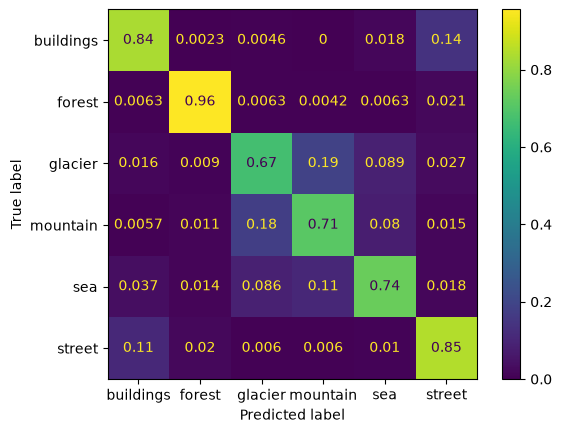

In [81]:
ConfusionMatrixDisplay.from_predictions(y_test_label, y_pred_label, normalize="true")
